# Final Exam BUS 458 — Loan Data Analysis
## Brynn Wellons 4/29/26

**Objective:** Your objective is to identify the key drivers of loan approval and recommend which lender should be prioritized for each customer to maximize total payout

### **Instructions**
- Follow the prompts in each section of this notebook.
- **Where you see a “Question,” answer it directly below in a Markdown (text) cell — not as a code comment.**
- Your **reasoning, interpretations, and insights** should be written in text cells, clearly separated from code.
- You are encouraged to add extra **code cells**, **visualizations**, or **short explanations** if they strengthen your analysis or help you justify decisions.
- Make sure your notebook runs cleanly from start to finish without errors.


In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Load Data (via Google Drive or direct upload)

In [81]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [82]:
# Load the data from Google Drive
df = pd.read_csv('/content/drive/MyDrive/loan_data_analysis_final.csv')

In [83]:
# Check first 5 rows of dataframe
df.head()
# Check last 5 rows of dataframe
df.tail()

,User ID,applications,Reason,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Fico_Score_group,Employment_Status,Employment_Sector,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Lender,Approved,bounty
99995,fffb48e8-fc77-49fe-ab4e-e99a0829a788,1,other,40000,50000.0,NaN,good,full_time,consumer_staples,5800.0,1460,0,A,0,0
99996,fffb63e2-b1d6-4d73-b766-44ba50203c00,1,major_purchase,70000,79000.0,621.0,fair,full_time,consumer_staples,5691.0,2705,0,B,0,0
99997,fffba42b-265f-4269-a6d5-c8db7e3bd430,1,major_purchase,80000,96000.0,NaN,poor,full_time,real_estate,3312.0,1210,0,C,0,0
99998,fffd8e45-d5f8-4b06-b1a4-2d4bf527ee51,1,debt_conslidation,90000,109000.0,NaN,poor,full_time,industrials,4597.0,1420,0,C,0,0
99999,fffe836d-3176-4766-81c0-8812d1d9a0a6,1,other,50000,57000.0,NaN,poor,full_time,materials,2533.0,2648,0,A,0,0


In [84]:
# Drop columns that have no variation or are unique
# Identify columns with no variation (all values are the same)
no_variation_cols = [col for col in df.columns if df[col].nunique() == 1]

# Identify columns with unique values (e.g., IDs that are not User ID, which is likely a key)
# User ID is often unique, but it might be a meaningful identifier, so let's exclude it for now
unique_cols = [col for col in df.columns if df[col].nunique() == len(df) and col != 'User ID']

# Combine the lists of columns to drop
columns_to_drop = list(set(no_variation_cols + unique_cols))

print(f"Columns with no variation: {no_variation_cols}")
print(f"Columns with unique values (excluding User ID): {unique_cols}")
print(f"Columns to drop: {columns_to_drop}")

df_initial_shape = df.shape
# Drop the identified columns if any
if columns_to_drop:
    df = df.drop(columns=columns_to_drop)
    print(f"Dropped columns: {columns_to_drop}")
    print(f"DataFrame shape before dropping: {df_initial_shape}")
    print(f"DataFrame shape after dropping: {df.shape}")
else:
    print("No columns with no variation or unique values (excluding User ID) found to drop.")

Columns with no variation: ['applications']
Columns with unique values (excluding User ID): []
Columns to drop: ['applications']
Dropped columns: ['applications']
DataFrame shape before dropping: (100000, 15)
DataFrame shape after dropping: (100000, 14)


Understand the Data: Get a quick overview of the dataset structure and variable meanings before preprocessing.

In [85]:
print(df.info())
print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User ID                     100000 non-null  object 
 1   Reason                      100000 non-null  object 
 2   Granted_Loan_Amount         100000 non-null  int64  
 3   Requested_Loan_Amount       100000 non-null  float64
 4   FICO_score                  85000 non-null   float64
 5   Fico_Score_group            100000 non-null  object 
 6   Employment_Status           100000 non-null  object 
 7   Employment_Sector           93593 non-null   object 
 8   Monthly_Gross_Income        85000 non-null   float64
 9   Monthly_Housing_Payment     100000 non-null  int64  
 10  Ever_Bankrupt_or_Foreclose  100000 non-null  int64  
 11  Lender                      100000 non-null  object 
 12  Approved                    100000 non-null  int64  
 13  bounty         

## 1. Preprocessing

### 1.1 Handling Missing Values

**Question:** Why is median imputation often preferable to mean imputation for income and FICO?


**Answer:** Median imputation is generally preferred for income and FICO scores because income and FICO scores are often not normally distributed. Income distributions are usually right-skewed where a small amount of high earners pull the mean up, and FICO scores can similarly be skewed. The mean is highly sensitive to outliers and skewed distributions, so it may not accurately represent the typical value by distorting the variance and relationship with the other variables. The median, on the other hand, is not sensitive to outliers and skewness, so it is more representative of a central tendency for the data. The imputed median helps preserve the data integrity and is more realistic than a mean which is heavily impacted by extreme values.




In [86]:
# Inspect missing values
missing_values = df.isnull().sum()
missing_percentage = 100 * df.isnull().sum() / len(df)
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)
print(missing_df)

                      Missing Count  Missing Percentage
FICO_score                    15000              15.000
Monthly_Gross_Income          15000              15.000
Employment_Sector              6407               6.407


In [87]:
# Fix: NameError - Ensure 'df' is defined by running all preceding cells from the start.
# Apply imputation as instructed in the instructions pdf (create copies so original rows can be restored if needed)

# Impute
# Create a copy of the DataFrame before imputation
df_imputed = df.copy()

# Impute FICO_score and Monthly_Gross_Income with their medians
df_imputed['FICO_score'] = df_imputed['FICO_score'].fillna(df_imputed['FICO_score'].median())
df_imputed['Monthly_Gross_Income'] = df_imputed['Monthly_Gross_Income'].fillna(df_imputed['Monthly_Gross_Income'].median())

# Impute Employment_Sector with 'Unknown' as per instructions
df_imputed['Employment_Sector'] = df_imputed['Employment_Sector'].fillna('Unknown')

# Verify that there are no more missing values
print("Missing values after imputation:")
print(df_imputed.isnull().sum()[df_imputed.isnull().sum() > 0])

df = df_imputed.copy() # Update the main df to the imputed version

Missing values after imputation:
Series([], dtype: int64)


### 1.2 Outliers Detection and Removal

**Question:**
Which features had the most outliers, and what impact could they have on the model?

**Answer**: Based on the boxplots, monthly housing payment, granted loan amount, requested loan amount, and monthly gross income all have a large number of outliers on the higher end, indicating right-skewed distributions. While FICO score seems to have a more concentrated distribution, it also shows some outliers on both ends. The impacts of outliers on the model are skewed summary statistics such as mean and standard deviation, larger errors and poorer model performance with the potential for bad generalization and overfitting, and consequently misleading conclusions.

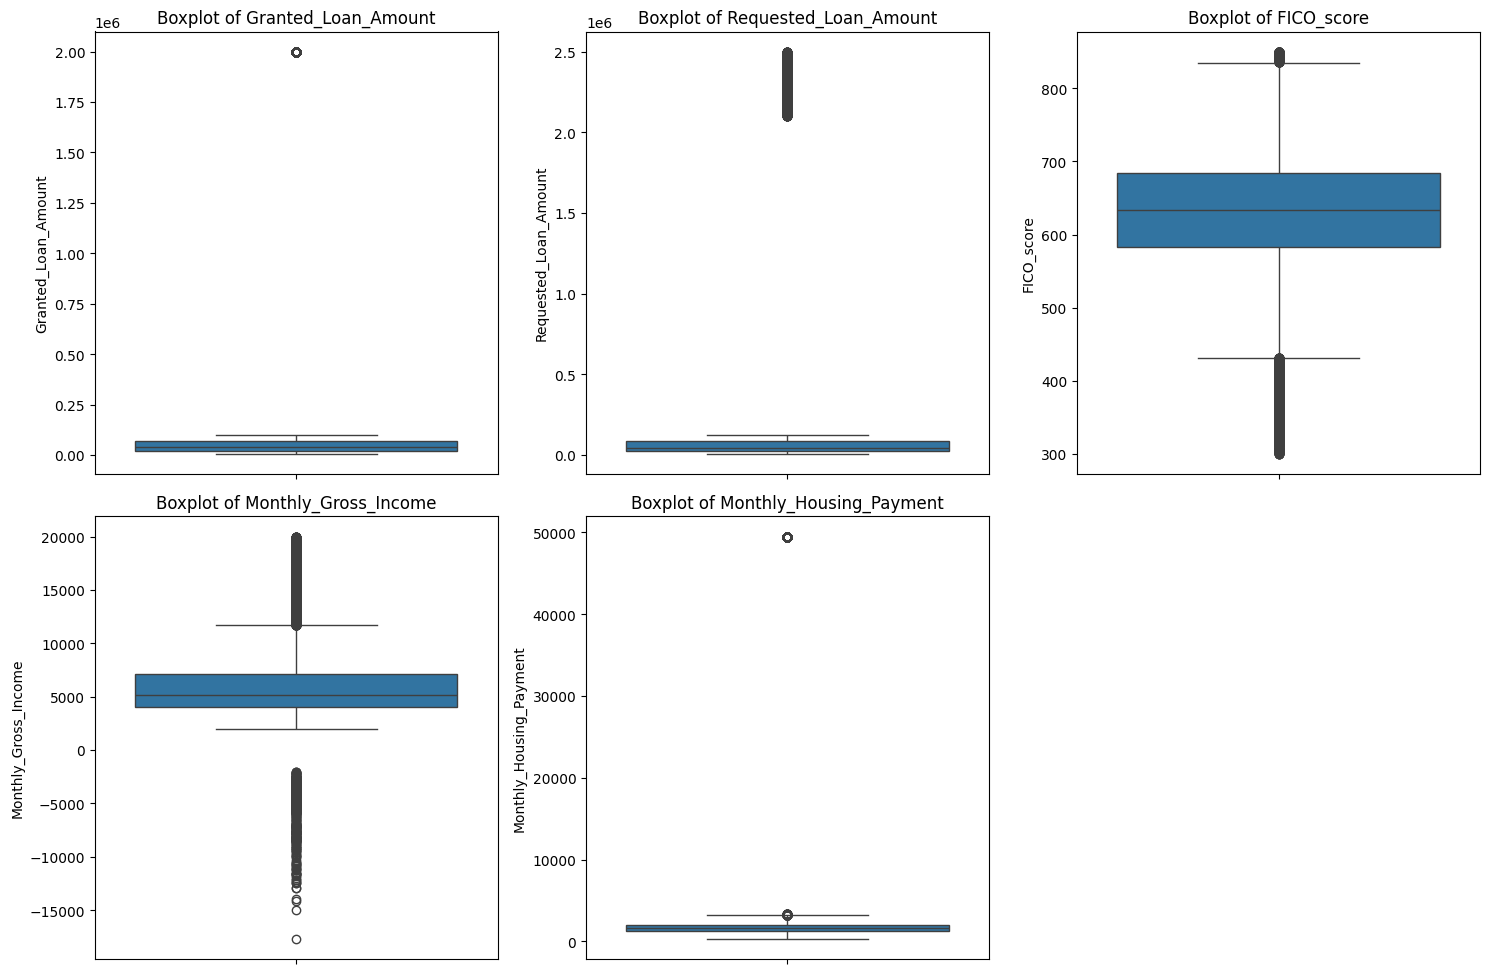

In [88]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

numeric_cols = ['Granted_Loan_Amount', 'Requested_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

# Boxplots to highlight outliers for numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i) # Adjust subplot grid based on number of columns
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [89]:
# Remove Outliers using Z-score

from scipy import stats
import numpy as np

# Compute Z-scores for only numeric columns
z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))

# Choose threshold
threshold = 3  # common choice: 3 standard deviations

# Identify rows to keep (all Z-scores <= threshold)
rows_to_keep = (z_scores < threshold).all(axis=1)

# Track counts before/after
before_count = df.shape[0]
df_clean = df[rows_to_keep].copy()
after_count = df_clean.shape[0]

print(f"Outlier removal complete:")
print(f"Rows before: {before_count}")
print(f"Rows after:  {after_count}")
print(f"Rows removed: {before_count - after_count}")


Outlier removal complete:
Rows before: 100000
Rows after:  95691
Rows removed: 4309


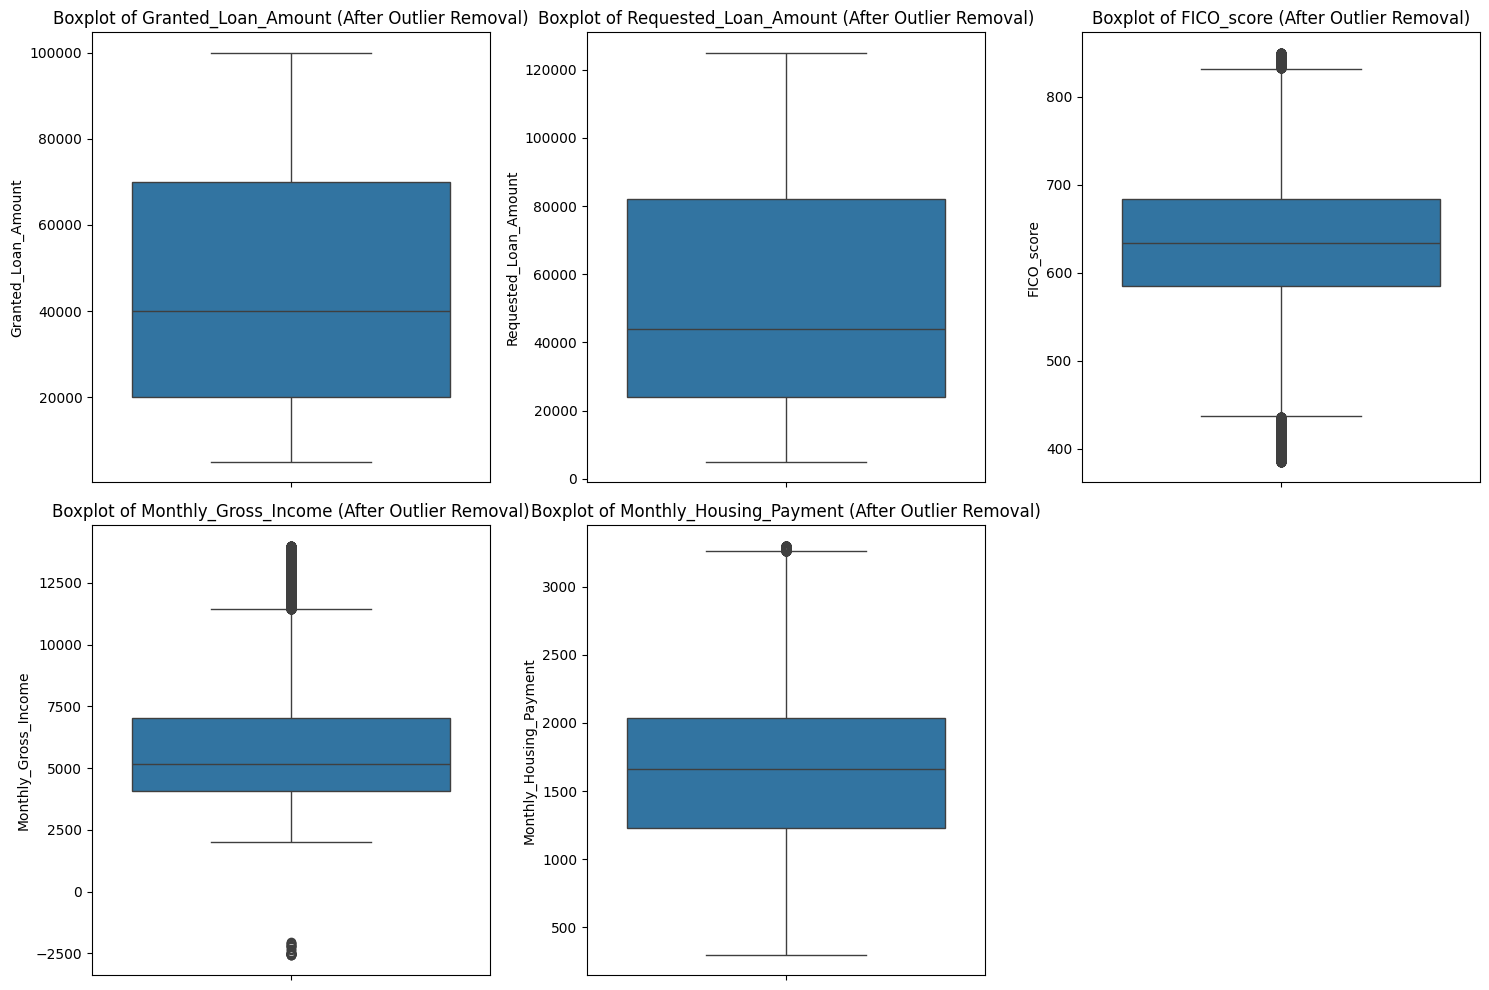

In [90]:
# BoxPlots after outlier removal
numeric_cols = ['Granted_Loan_Amount', 'Requested_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i) # Adjust subplot grid based on number of columns
    sns.boxplot(y=df_clean[col])
    plt.title(f'Boxplot of {col} (After Outlier Removal)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

**Question:**
Why do we need to remove or treat outliers? Provide reasoning based on model performance or data integrity.

**Answer** : We need to remove or treat outliers because they can significantly impact both model performance and data integrity. Outliers can distort statistical measures like mean and standard deviation, making them less representative of the typical data. Outliers can lead to biased models with reduced accuracy by disproportionately influencing the model's parameters or decision boundaries. By treating outliers, models are more reliable and can generalize unseen data better.


**Question:**
Is there a difference between boxplots before and after outlier removal?

**Answer** : Yes, there is a clear difference between the boxplots before and after outlier removal. The boxplots after outlier removal for granted loan amount, requested loan amount, monthly gross income, and monthly housing payment all show a much tighter distribution, with significantly shorter whiskers and far fewer individual data points marked as outliers. This indicates that the extreme values that were previously pulling the whiskers far out or appearing as numerous individual points have been properly removed, resulting in a cleaner and more concentrated view of the central tendency and spread of these variables. FICO score also appears slightly more concentrated.

### 1.3 Redundancy & Correlation Check (5 Marks)

Detect duplicate data and multicollinearity.

**Question:**
Which numerical variables appear most strongly correlated with each other?

**Answer:** The two numerical variables for requested loan amount and granted loan amount are most strongly correlated with a correlation coefficient of 0.99.



**Question:**
Which numerical and categorical are strongly corelated to each other?

**Answer:**
Based on the correlation ratios shown, the strongest meaningful correlations between numerical and categorical variables are FICO score and FICO score group, monthly gross income and employment status, and monthly gross income and FICO score group. The first pairing makes sense because FICO score group is derived from FICO score, and they have strong correlation. There is moderate correlation between the second pair, suggesting that different employment statuses have differences in monthly gross income. The third pair has a weaker correlation, indicating some relationship exists between income brackets and FICO score groups.

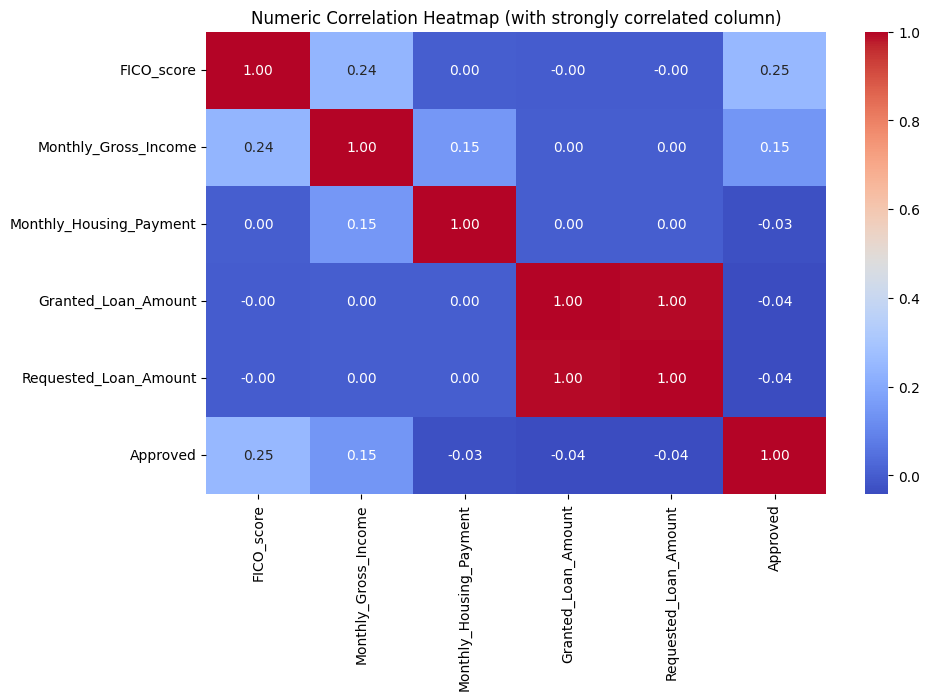

In [91]:
# Correlation between numerical features
numeric_cols = ['FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment', 'Granted_Loan_Amount','Requested_Loan_Amount', 'Approved']

# Plot correlation matrix, identify highly correlated pairs automatically (|corr|>0.95, excluding self-correlation)
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Numeric Correlation Heatmap (with strongly correlated column)")
plt.show()

Top 10 Numeric-Categorical Correlation Ratios (η²):
Granted_Loan_Amount - User ID: η² = 1.000 (η = 1.000)
Requested_Loan_Amount - User ID: η² = 1.000 (η = 1.000)
FICO_score - User ID: η² = 1.000 (η = 1.000)
Monthly_Gross_Income - User ID: η² = 1.000 (η = 1.000)
Monthly_Housing_Payment - User ID: η² = 1.000 (η = 1.000)
Ever_Bankrupt_or_Foreclose - User ID: η² = 1.000 (η = 1.000)
FICO_score - Fico_Score_group: η² = 0.729 (η = 0.854)
Monthly_Gross_Income - Employment_Status: η² = 0.246 (η = 0.496)
Monthly_Gross_Income - Fico_Score_group: η² = 0.074 (η = 0.272)
Monthly_Gross_Income - Employment_Sector: η² = 0.070 (η = 0.265)


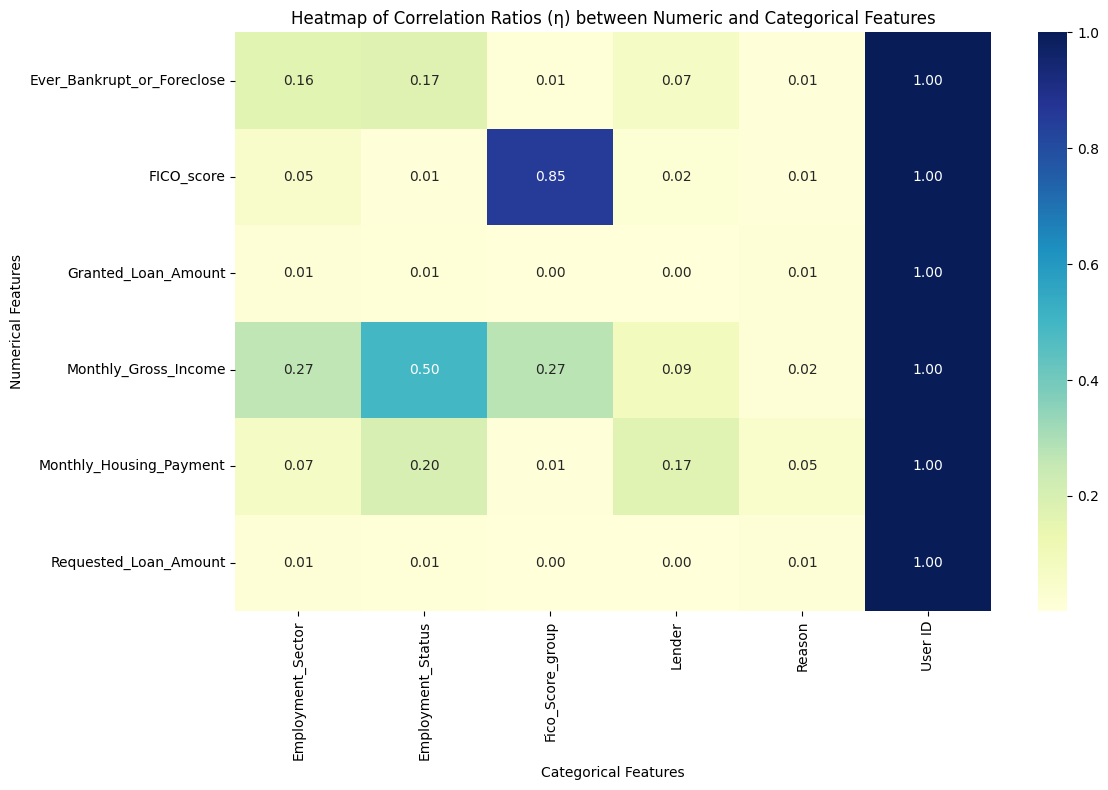

In [92]:
# Correlation between Numeric and Categorical Variables (Correlation Ratio / η²)
from scipy import stats
import pandas as pd

def correlation_ratio(categories, values):
    df_temp = pd.DataFrame({'categories': categories, 'values': values})
    overall_mean = df_temp['values'].mean()

    # Calculate Sum of Squares Total (SST)
    sst = ((df_temp['values'] - overall_mean) ** 2).sum()

    if sst == 0: # Avoid division by zero if all values are the same
        return 0

    # Calculate Sum of Squares Between (SSB)
    grouped = df_temp.groupby('categories')['values']
    ssb = (grouped.size() * (grouped.mean() - overall_mean) ** 2).sum()

    eta_squared = ssb / sst
    return np.sqrt(eta_squared)

# test all numeric–categorical pairs
num_cat_results = []


# Identify categorical and numerical columns
categorical_cols_clean = df_clean.select_dtypes(include='object').columns.tolist()
numeric_cols_clean = df_clean.select_dtypes(include=np.number).columns.tolist()


numeric_cols_for_eta = [col for col in numeric_cols_clean if col not in ['bounty', 'Approved', ]]
categorical_cols_for_eta = [col for col in categorical_cols_clean]


for num_col in numeric_cols_for_eta:
    for cat_col in categorical_cols_for_eta:
        eta = correlation_ratio(df_clean[cat_col], df_clean[num_col])
        num_cat_results.append((num_col, cat_col, eta))

num_cat_results = sorted(num_cat_results, key=lambda x: x[2], reverse=True)
print("Top 10 Numeric-Categorical Correlation Ratios (η²):")
for num_col, cat_col, eta in num_cat_results[:10]:
    print(f"{num_col} - {cat_col}: η² = {eta**2:.3f} (η = {eta:.3f})")


# Reorganize the correlation ratio results into a pivot table/matrix for heatmap
eta_matrix = pd.DataFrame(num_cat_results, columns=['Numerical_Feature', 'Categorical_Feature', 'Eta'])
eta_pivot = eta_matrix.pivot(index='Numerical_Feature', columns='Categorical_Feature', values='Eta')

# Plot the heatmap of correlation ratios (Eta)
plt.figure(figsize=(12, 8))
sns.heatmap(eta_pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap of Correlation Ratios (η) between Numeric and Categorical Features")
plt.xlabel("Categorical Features")
plt.ylabel("Numerical Features")
plt.tight_layout()
plt.show()

**Questions:** What features will you consider dropping after analyzing the graphs above?

**Answer** :
Based on the correlation analysis, I would consider dropping user ID, requested loan amount, and FICO score group. User ID is a unique identifier and does not contain predictive information. It also has high correlation with all numerical features, showing that this is not a causal relationship. Including user ID would likely lead to overfitting. I would drop requested loan amount because of its high correlation with granted loan amount. Keeping both variables would result in multicollinearity. Because granted loan amount is the actual loan amount outcome, that is the variable I want to keep. I would finally drop FICO score groups because it is highly correlated with FICO score. FICO score is a continuous numerical variable and likely provides more granular information, so we can drop FICO score group to eliminate redundancy and potential multicollinearity.


> *Note: For Decision Tree models, you do not need to remove or adjust for collinearity. The algorithm can naturally handle correlated features through its splitting mechanism. However, for Logistic Regression, multicollinearity can distort coefficient estimates and make interpretations unreliable. In that case, you may consider removing one variable from highly correlated pairs.

## 2. Exploratory Data Analysis

### 2.1 Target Variable Distribution

Analyze the distribution of the target variable (Approved) to understand class balance in loan approval outcomes.


**Question:**
Is the dataset balanced or imbalanced? Briefly explain the implication for modeling.


**Answer:**
The dataset is highly imbalanced because are significantly more denied loan applications than approved loan applications. In modeling, an imbalanced dataset can lead to a biased model, poor predictive performance, and misleading evaluation metrics. The model would be biased toward the majority class of denied applications and struggle to learn the patterns of the minority class of approved applications. This results in low recall and precision for approved loans, meaning in the real world, there would be many false negatives, where many legitimate applications could be wrongly rejected. Additionally, there could be many false positives, where many bad applications could be wrongly approved. A model that predicts that mostly all applications will be denied would not be useful in practice. Metrics such as precision, recall, F1-score, and AUC-ROC are needed to evaluate the model.


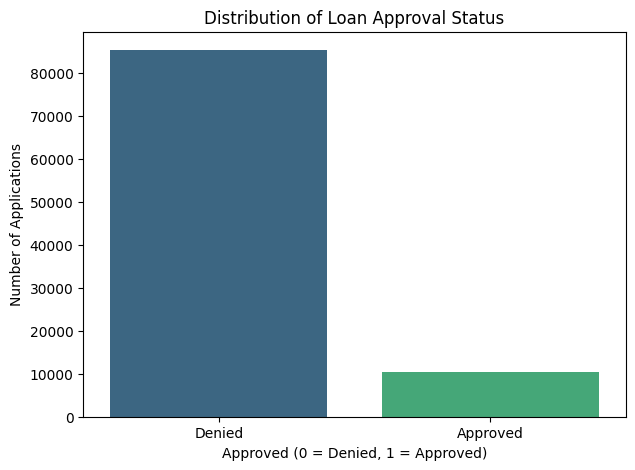


Loan Approval Counts:
Approved
0    85309
1    10382
Name: count, dtype: int64

Loan Approval Percentages:
Approved
0    89.15
1    10.85
Name: proportion, dtype: float64


In [93]:
# Plot 'Approved' to visualise the count and balance
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(x='Approved', data=df_clean, palette='viridis', hue='Approved', legend=False)
plt.title('Distribution of Loan Approval Status')
plt.xlabel('Approved (0 = Denied, 1 = Approved)')
plt.ylabel('Number of Applications')
plt.xticks(ticks=[0, 1], labels=['Denied', 'Approved'])
plt.show()

approval_counts = df_clean['Approved'].value_counts()
approval_percentages = df_clean['Approved'].value_counts(normalize=True) * 100

print("\nLoan Approval Counts:")
print(approval_counts)
print("\nLoan Approval Percentages:")
print(approval_percentages.round(2))


### 2.2 Distribution of Numerical Variables by Approval

Explore how key numerical variables differ between approved and rejected loan applications.


**Question:**
Which numerical variable is the most helpful variable ( most crucial predictor)?

**Answer:**
FICO score is the most helpful and crucial numerical predictor for loan approval. The distribution plots and the strong correlation shown in the analysis indicate that higher FICO scores are strongly associated with a higher likelihood of loan approval.

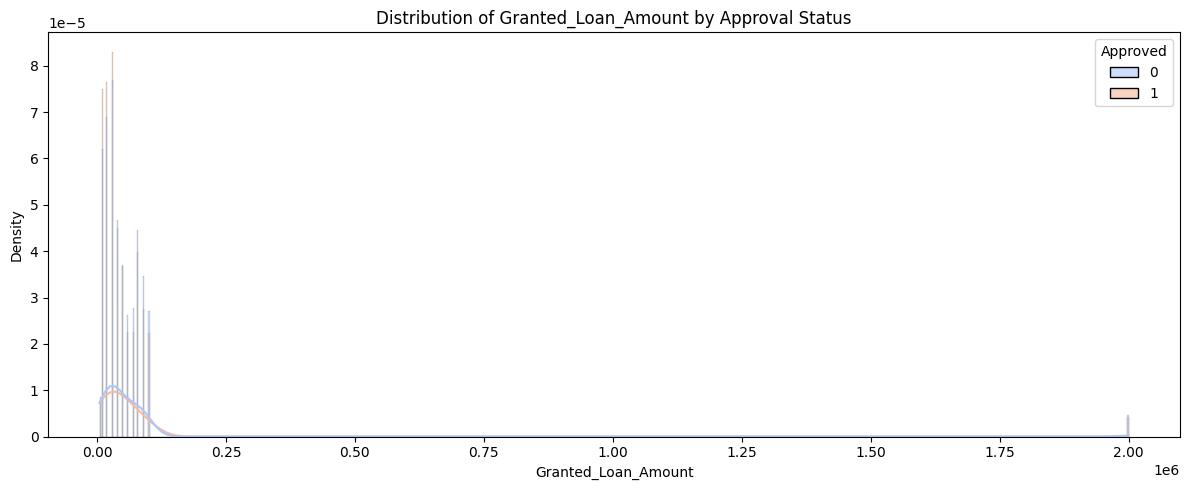

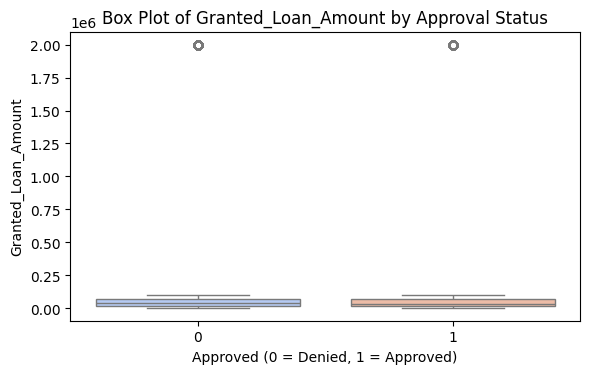

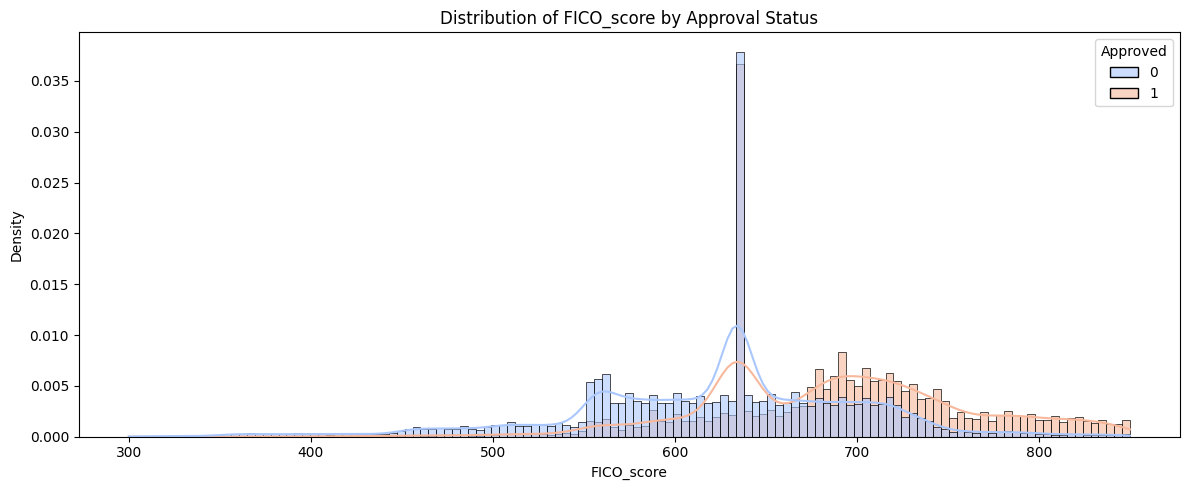

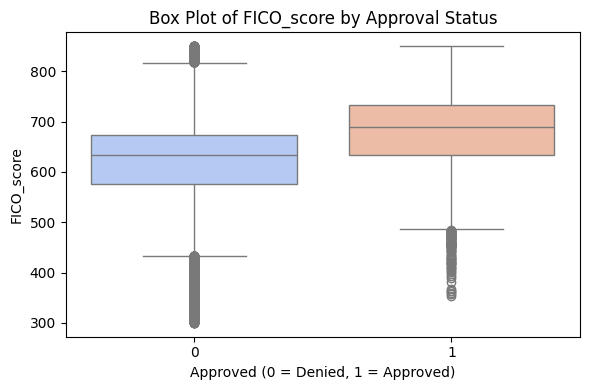

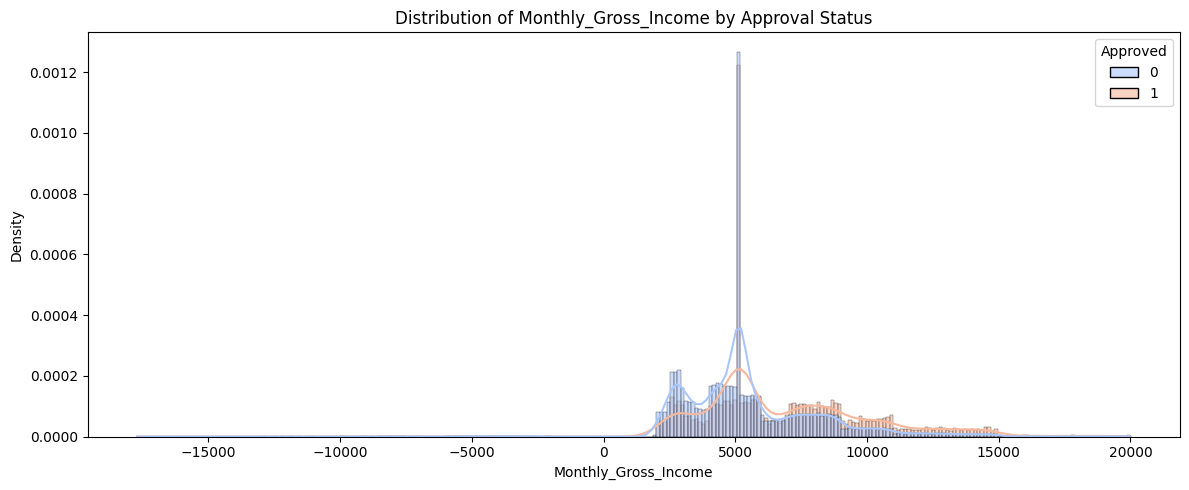

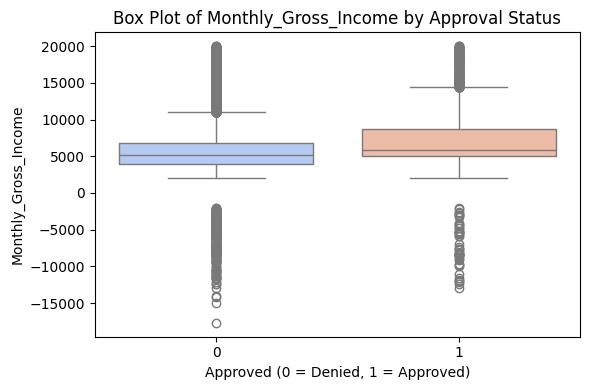

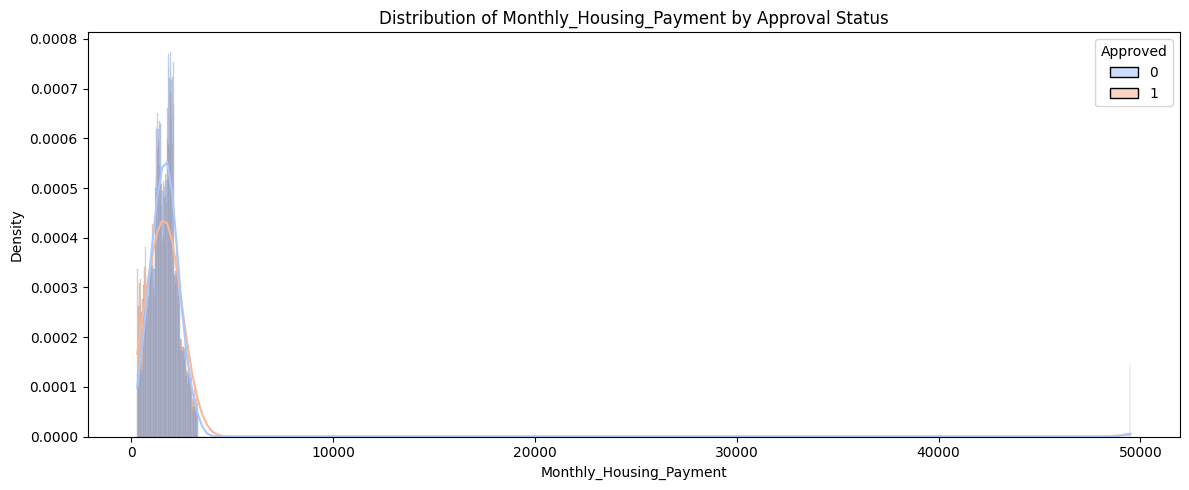

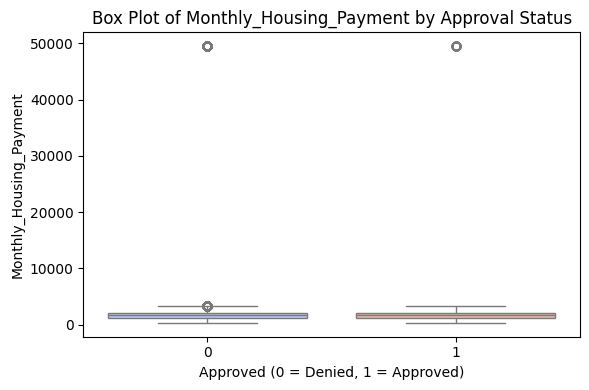

In [94]:
# Visualise numerical variables against target variable

numerical_cols = ['Granted_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

for col in numerical_cols:
    plt.figure(figsize=(12,5))
    sns.histplot(
        data=df,
        x=col,
        hue='Approved',
        kde=True,
        stat='density',
        common_norm=False,
        palette='coolwarm',
        alpha=0.6
    )
    plt.title(f'Distribution of {col} by Approval Status')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(
        data=df,
        x='Approved',
        y=col,
        hue='Approved',
        palette='coolwarm',
        legend=False
    )
    plt.title(f'Box Plot of {col} by Approval Status')
    plt.xlabel('Approved (0 = Denied, 1 = Approved)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


### 2.3 Categorical Variables and Approval

Analyze how categorical variables (such as Employment_Sector, Loan_Purpose, or Residence_Type) relate to the loan approval outcome.


**Question:**
Which categorical variable appears to have the strongest relationship with loan approval, and how can you tell?

**Answer:**
FICO score group appears to have the strongest relationship with loan approval. The approval rates for FICO score group vary drastically, from a low of 2.78% for 'poor' to a high of 45.80% for 'excellent'. This wide range indicates a very strong discriminatory power, as the category alone gives a lot of insight about the likelihood of approval. Also, the correlation ratio between FICO score and FICO score group was very high While we established that FICO score group is derived from FICO score, its distinct categories show a large impact on the target variable, making it the most influential categorical predictor.


**Question:**
Are there any categories (e.g., Reason, Employment_Status) that appear to have minimal predictive value? Justify your answer with approval rate differences.

**Answer:**
Reason is the cateory that appears to have minimal predictive value. The approval rates across all reason categories are very similar, ranging only from 10.81% to 11.27%, a difference of less than 0.5%. The narrow spread suggests that the reason an applicant applies for a loan has very little affect on their approval likelihood.

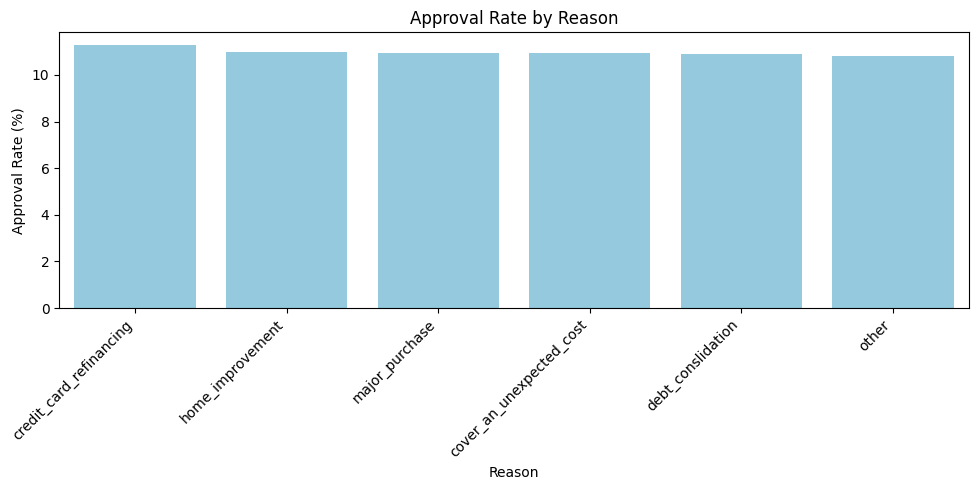


Approval Rate by Reason:
Reason
credit_card_refinancing     11.27
home_improvement            10.98
major_purchase              10.95
cover_an_unexpected_cost    10.93
debt_conslidation           10.89
other                       10.81
Name: Approved, dtype: float64


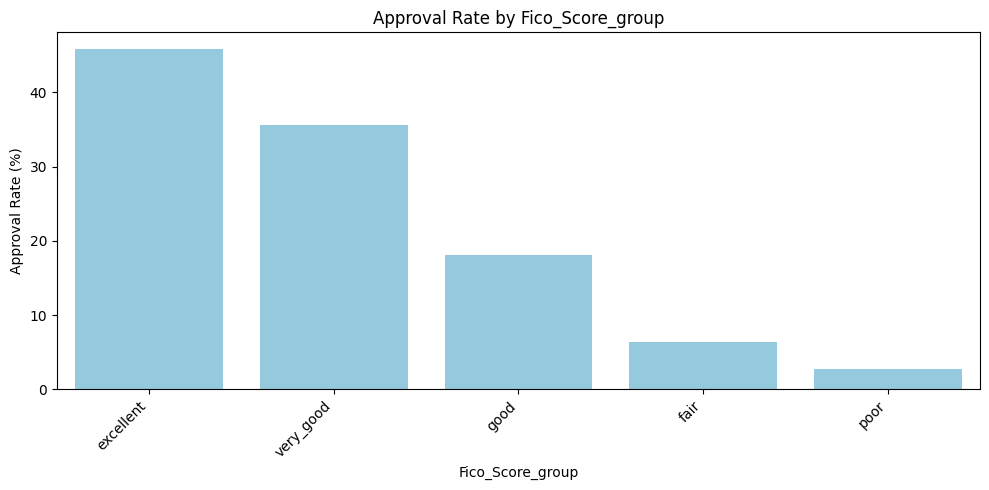


Approval Rate by Fico_Score_group:
Fico_Score_group
excellent    45.80
very_good    35.65
good         18.06
fair          6.44
poor          2.78
Name: Approved, dtype: float64


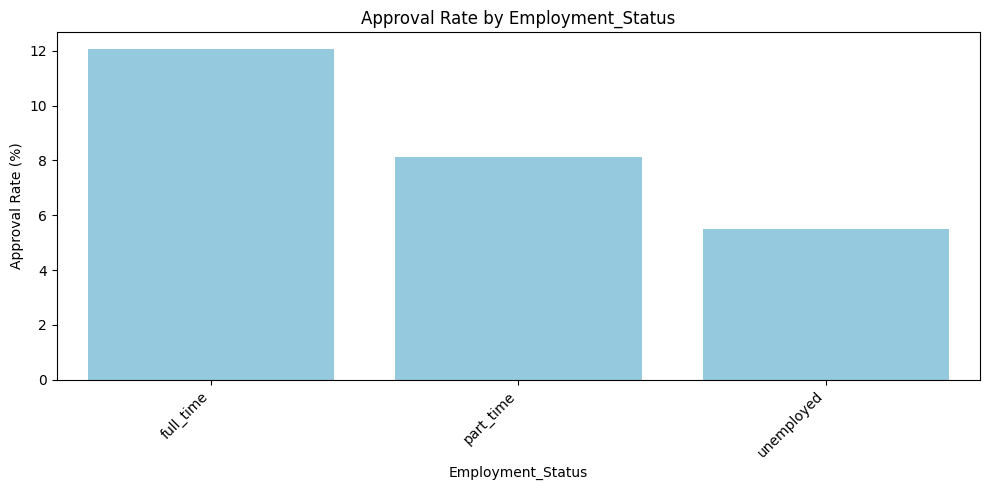


Approval Rate by Employment_Status:
Employment_Status
full_time     12.07
part_time      8.12
unemployed     5.49
Name: Approved, dtype: float64


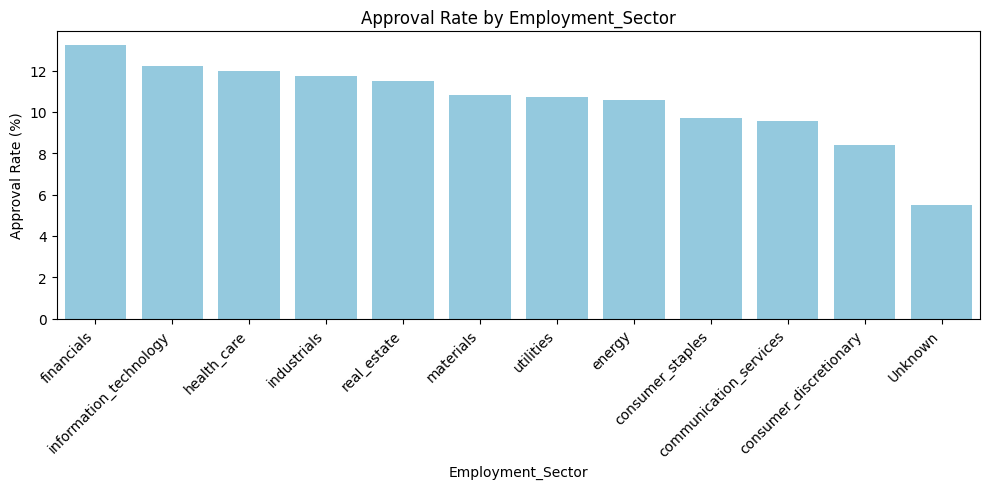


Approval Rate by Employment_Sector:
Employment_Sector
financials                13.24
information_technology    12.20
health_care               11.97
industrials               11.75
real_estate               11.50
materials                 10.83
utilities                 10.71
energy                    10.60
consumer_staples           9.68
communication_services     9.57
consumer_discretionary     8.42
Unknown                    5.49
Name: Approved, dtype: float64


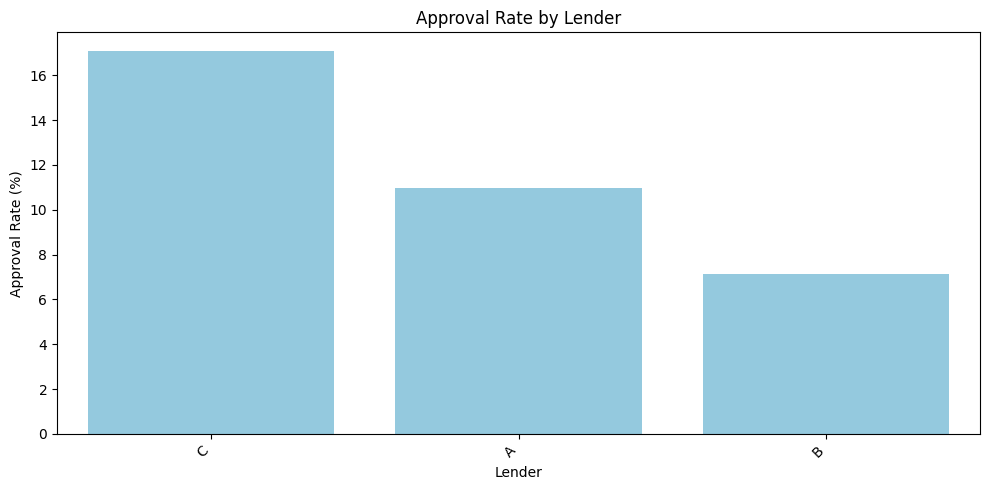


Approval Rate by Lender:
Lender
C    17.06
A    10.97
B     7.13
Name: Approved, dtype: float64


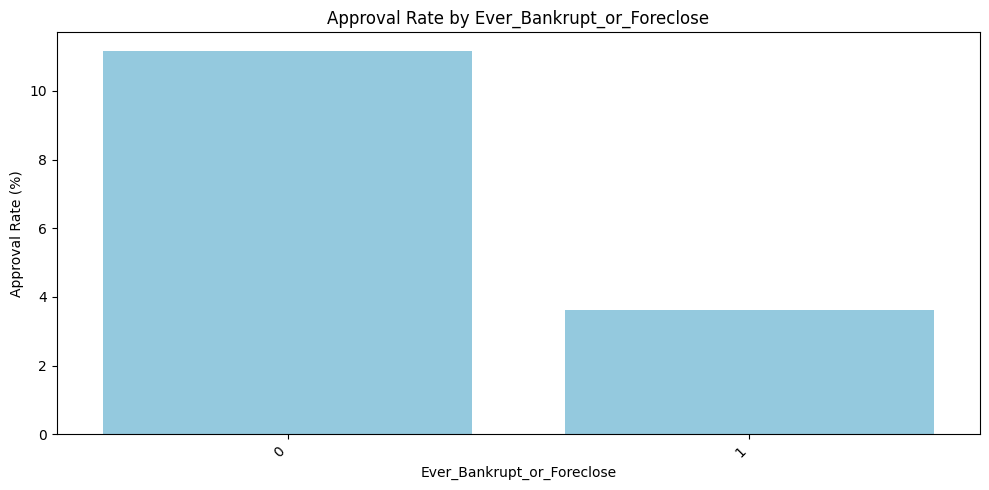


Approval Rate by Ever_Bankrupt_or_Foreclose:
Ever_Bankrupt_or_Foreclose
0    11.15
1     3.61
Name: Approved, dtype: float64


In [95]:
# Visualise categorical variables against target variable

categorical_cols = [
    'Reason', 'Fico_Score_group', 'Employment_Status',
    'Employment_Sector', 'Lender', 'Ever_Bankrupt_or_Foreclose'
]

for col in categorical_cols:
    approval_rates = df.groupby(col)['Approved'].mean().sort_values(ascending=False) * 100

    plt.figure(figsize=(10,5))
    sns.barplot(x=approval_rates.index, y=approval_rates.values, color='skyblue')
    plt.title(f'Approval Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Approval Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\nApproval Rate by {col}:\n{approval_rates.round(2)}")


### Cross Feature plots for multi-dimensional analysis.


Generating Grouped Bar Plot: Approval Rate by FICO Score Group and Lender...


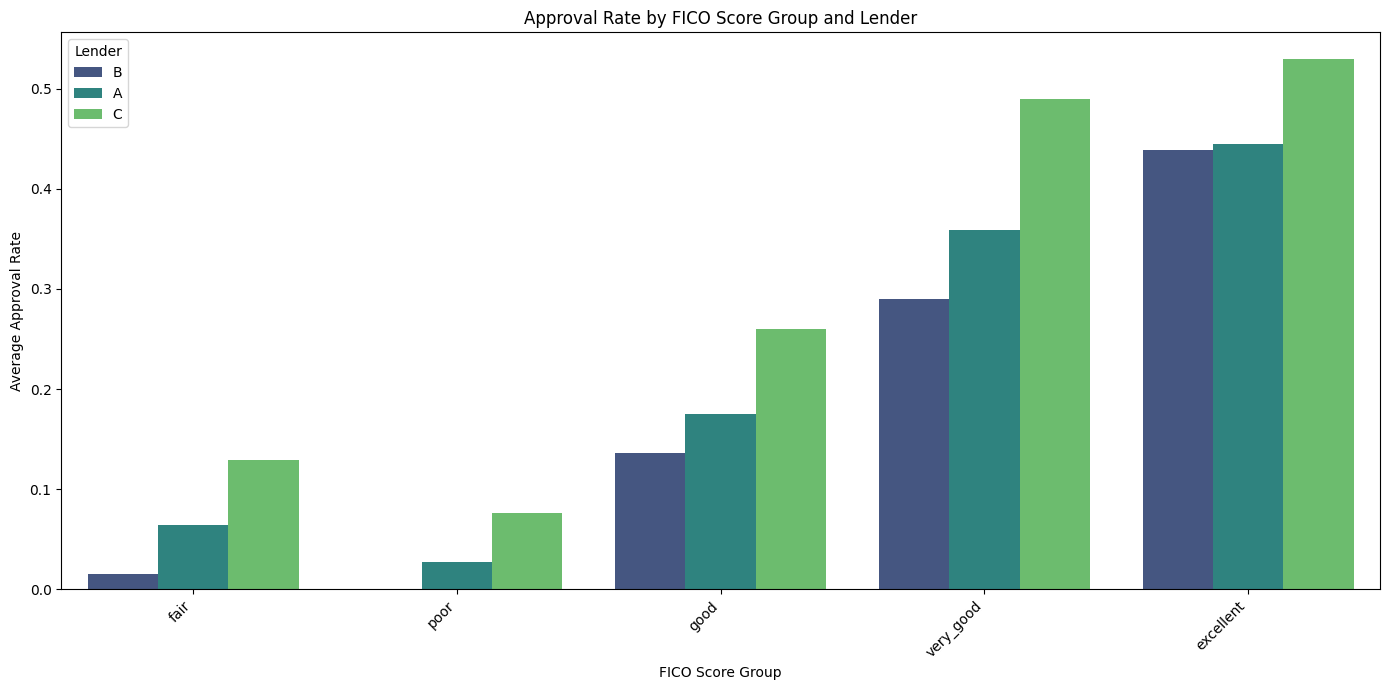

In [96]:
# --- 1. Grouped Bar Plot: Approval Rate by FICO Score Group and Lender ---
print("\nGenerating Grouped Bar Plot: Approval Rate by FICO Score Group and Lender...")
plt.figure(figsize=(14, 7))
sns.barplot(data=df_clean, x='Fico_Score_group', y='Approved', hue='Lender', palette='viridis', errorbar=None)
plt.title('Approval Rate by FICO Score Group and Lender')
plt.xlabel('FICO Score Group')
plt.ylabel('Average Approval Rate')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Lender')
plt.tight_layout()
plt.show()


Generating Categorical vs. Numerical plot (Employment Status vs. Monthly Gross Income)...


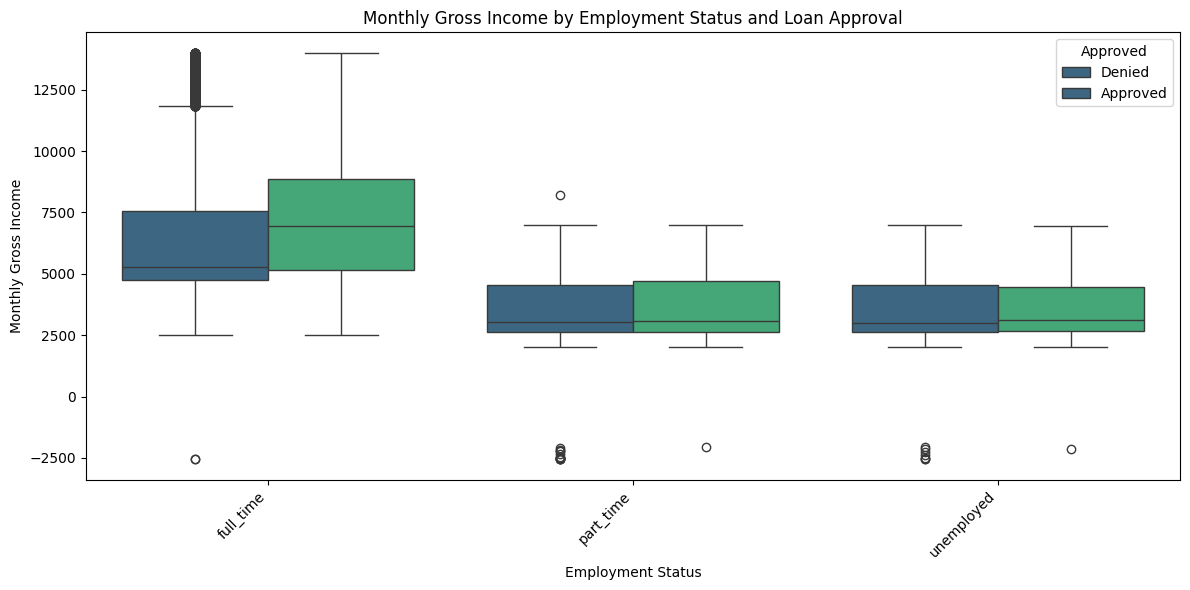

In [97]:
# --- 2. Categorical vs. Numerical Feature by Approval Status (Example: Employment Status vs. Income) ---
print("\nGenerating Categorical vs. Numerical plot (Employment Status vs. Monthly Gross Income)...")
plt.figure(figsize=(12, 6))
sns.boxplot(x='Employment_Status', y='Monthly_Gross_Income', hue='Approved', data=df_clean, palette='viridis')
plt.title('Monthly Gross Income by Employment Status and Loan Approval')
plt.xlabel('Employment Status')
plt.ylabel('Monthly Gross Income')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Approved', labels=['Denied', 'Approved'])
plt.tight_layout()
plt.show()


Generating Categorical vs. Numerical plot (Fico Score Group vs. Granted Loan Amount)...


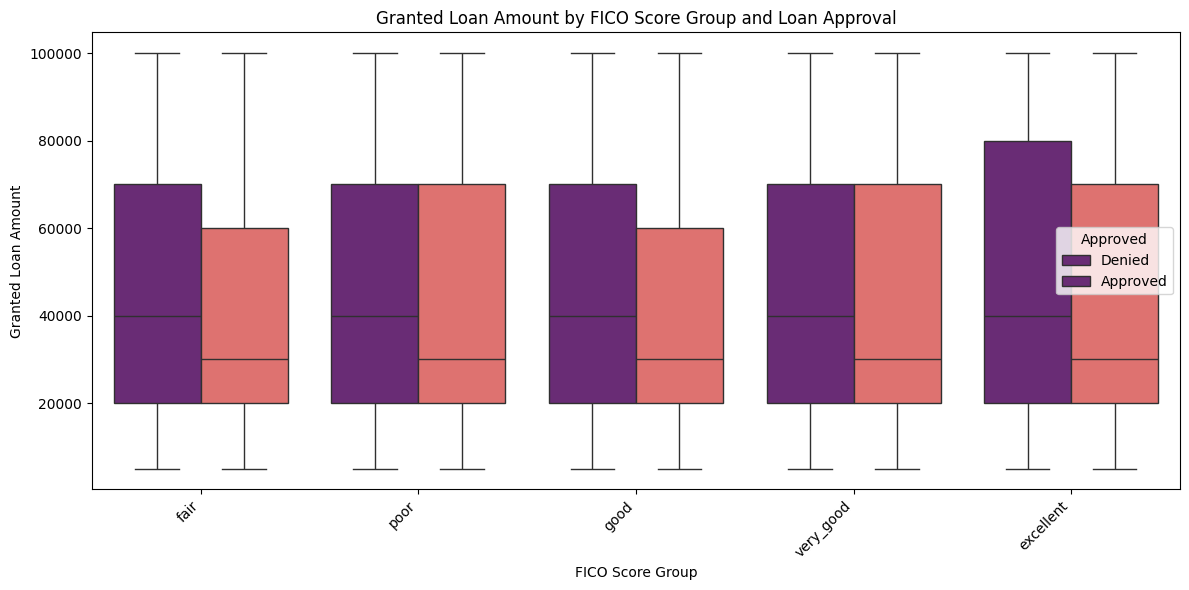

In [98]:
# --- 3. Categorical vs. Numerical Feature by Approval Status (Example: Fico Score Group vs. Granted Loan Amount) ---
print("\nGenerating Categorical vs. Numerical plot (Fico Score Group vs. Granted Loan Amount)...")
plt.figure(figsize=(12, 6))
sns.boxplot(x='Fico_Score_group', y='Granted_Loan_Amount', hue='Approved', data=df_clean, palette='magma')
plt.title('Granted Loan Amount by FICO Score Group and Loan Approval')
plt.xlabel('FICO Score Group')
plt.ylabel('Granted Loan Amount')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Approved', labels=['Denied', 'Approved'])
plt.tight_layout()
plt.show()

## 3.5 Business Insights from EDA

After completing your visualizations and cross-feature analyses, summarize your findings in the context of loan approval and lender matching.  
Use this section to connect data patterns to real-world meaning before building predictive models.


**Question:** Which variables are the most helpful in understanding if a customer is going to be approved or denied for a loan?  

**Answer**:
The most helpful variables in understanding loan approval are FICO score, granted loan amount, monthly gross income, and monthly housing payment. FICO score is by far the most crucial predictor. The distribution plots show that higher FICO scores correlate strongly with a much higher likelihood of approval. Granted loan amount shows that larger loan amounts tend to have lower approval rates, suggesting stricter criteria or higher risk assessment for bigger loans. Monthly gross income plays a role because approved applications seem to generally have higher monthly gross incomes compared to denied applicants. Monthly housing payment subtly indicates that lower housing payments relative to income might be associated with higher approval. Finally, there are also clear difference in approval rates between lenders, with lender A having a significantly higher approval rate. This suggests different criteria or risk tolerance between lenders.


**Question:** Are there any feature modifications or transformations that would improve the predictive power of a variable?  

**Answer**:
Interaction terms and ratio features would improve the predictive power of a variable. Creating interaction terms between FICO score and monthly fross income, or FICO score and granted loan amount, could capture scenarios where a high FICO score combined with a high income is a particularly strong indicator of approval. Creating ratios such a granted loan amount compared to monthly gross income would provide a more normalized view of an applicant's financial status.


**Question:** What is each lender’s average approval rate?  

**Answer**:
Lender A has an average approval rate of 14.24%. Lender B has an average approval rate of 8.36%. Lender C has an average approval rate of 7.72%


**Question:** Are there any clear differences between the three lenders in terms of which types of customers they approve?  

**Answer**:
Yes, Lender A has a substantially higher overall approval rate compared to Lender B and Lender C. Lender A likely has a more inclusive, less strict lending policy. Their risk tolerance is high, while Lenders B and C are more conservative.


**Question:** Are there variables that reliably predict a customer’s approval likelihood for a particular lender?  

**Answer**:
Yes, FICO score, monthly gross income and granted loan amount, ever bankrupt or foreclose, and reason for loan reliably predict a customer's approval likelihood for a particular lender. FICO score, as concluded previously, is a strong predictor across all lenders, where a high FICO score significantly increases the likelihood of approval, regardless of the lender. However, the threshold FICO score for an approval likely differs, with Lender A approving loans down to a fair FICO score, while Lenders B and C might only approve good or better scores. Monthly gross income and granted loan amount are strong predictors because they directly relate to an applicant's ability to repay the loan. Ever bankrupt or foreclose is a strong negative predictor for approval, since a history with bankruptcy or foreclosure is a red flag for lenders. Reason for loan can be a predictor because certain reasons might be favored by different lenders.

## 3. Model Training

### 3.1 Train/Test Split and Encoding

In [99]:
# Fix: NameError - Ensure 'df_clean' is defined by running all preceding cells from the start.
# Split dataset into train and test
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Rename your df to df_model and drop identified columns.
# Dropping: 'User ID', 'Requested_Loan_Amount', 'Fico_Score_group'
# These were identified as redundant or highly correlated in the EDA.
df_model = df_clean.drop(columns=['User ID', 'Requested_Loan_Amount', 'Fico_Score_group'])

# We have to drop target variable and bounty from X
X = df_model.drop(columns=['Approved', 'bounty'])
y = df_model['Approved']

# Encode categorical features using one-hot encoding
categorical_cols_X = X.select_dtypes(include='object').columns
X = pd.get_dummies(X, columns=categorical_cols_X, drop_first=True)

# Identify numerical columns for scaling
numerical_cols_X = X.select_dtypes(include=['int64', 'float64']).columns

# Set RANDOM_STATE = 42 for reproducibility.
random_state = 42

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)

# Apply StandardScaler to numerical features AFTER splitting
scaler = StandardScaler()
X_train[numerical_cols_X] = scaler.fit_transform(X_train[numerical_cols_X])
X_test[numerical_cols_X] = scaler.transform(X_test[numerical_cols_X])

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (76552, 25)
Shape of X_test: (19139, 25)
Shape of y_train: (76552,)
Shape of y_test: (19139,)


### 3.2 Logistic Regression Model
Build and interpret a Logistic Regression model to predict the likelihood of loan approval (Approved = 1).

**Question**
How accurate is the model on the test data, and what does this imply about its predictive strength?

**Answer**
The logistic regression model has an overall accuracy of 0.69 on the test data, but because the dataset is imbalanced, it could be misleading. A better measure of its predictive strength is the AUC-ROC score, which is 0.7661. This indicates the model has moderately good discriminatory power, and it can distinguish between approved and denied loans reasonably well. The model also achieves a recall of 0.70 for the approved class, meaning it correctly identifies 70% of all actual approved loans. However, the precision for approved is 0.22, meaning that when the model predicts an approval, it is only correct 22% of the time, leading to a higher number of false positives. While the raw accuracy is not exceptionally high, the AUC-ROC score and recall for the positive class demonstrate that the logistic regression model has meaningful predictive strength in identifying loan approvals, especially when considering the imbalanced nature of the dataset.

In [100]:
from sklearn.linear_model import LogisticRegression

# Train logistic regression model
logistic_model = LogisticRegression(random_state=random_state, solver='liblinear', class_weight='balanced') # 'balanced' to handle class imbalance
logistic_model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.69      0.80     17063
           1       0.22      0.70      0.33      2076

    accuracy                           0.69     19139
   macro avg       0.58      0.70      0.57     19139
weighted avg       0.87      0.69      0.75     19139

Logistic Regression ROC AUC Score: 0.7661


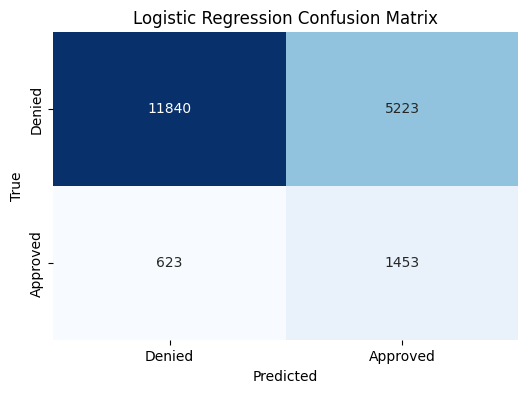

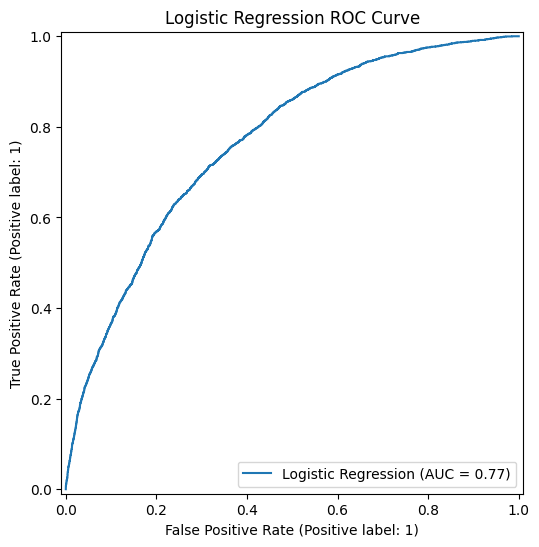

In [101]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_logistic = logistic_model.predict(X_test)
y_pred_proba_logistic = logistic_model.predict_proba(X_test)[:, 1]

# Classification Report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logistic))

# ROC AUC Score
roc_auc_logistic = roc_auc_score(y_test, y_pred_proba_logistic)
print(f"Logistic Regression ROC AUC Score: {roc_auc_logistic:.4f}")

# Confusion Matrix
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Denied', 'Approved'], yticklabels=['Denied', 'Approved'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# ROC Curve
plt.figure(figsize=(8, 6))
ax = plt.gca()
roc_display = RocCurveDisplay.from_estimator(logistic_model, X_test, y_test, ax=ax, name='Logistic Regression')
plt.title('Logistic Regression ROC Curve')
plt.show()

### 3.2 Decision Tree Classifier Model

Build and interpret a Decision Tree Classifier Model to predict the likelihood of loan approval (Approved = 1).



**Question**
How does the Decision Tree’s accuracy and AUC compare to the Logistic Regression model?

The decision tree (0.83) shows a higher overall accuracy compared to the logistic regression model (0.69). The logistic regression model (0.7661) significantly outperforms the decision tree (0.5717) in its ability to distinguish between approved and denied loans. Logistic regression (0.70) is much better at identifying actual approved loans (minority class) than the decision tree (0.24). Both models have low precision for approved loans, with logistic regression at 0.22 and decision tree at 0.23. Logistic regression has a much higher F1-score (0.33) for the positive class compared to the decision tree (0.24), indicating better balance between precision and recall for approved loans. While the decision tree has a higher overall accuracy, this is misleading for an imbalanced dataset. Its significantly lower AUC-ROC score and poor recall for the minority class of approved loans indicate that it struggles to correctly identify positive cases. In contrast, the logistic regression model, despite a lower overall accuracy, has a much better AUC-ROC score and significantly higher recall for the approved class, making it more effective at identifying potential loan approvals.

In [102]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=random_state, class_weight='balanced') # 'balanced' to handle class imbalance
decision_tree_model.fit(X_train, y_train)


DecisionTreeClassifier(class_weight='balanced', random_state=42)

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90     17063
           1       0.22      0.23      0.23      2076

    accuracy                           0.83     19139
   macro avg       0.56      0.57      0.57     19139
weighted avg       0.83      0.83      0.83     19139

Decision Tree ROC AUC Score: 0.5668


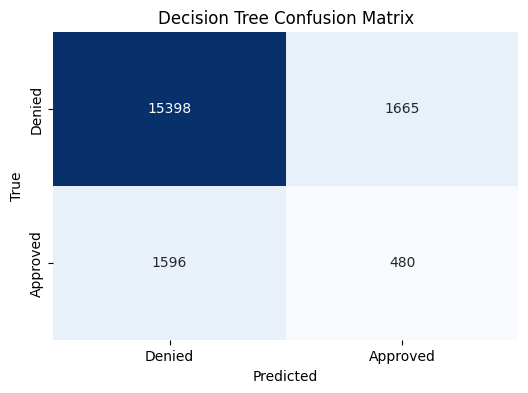

In [103]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

y_pred_tree = decision_tree_model.predict(X_test)
y_pred_proba_tree = decision_tree_model.predict_proba(X_test)[:, 1]

# Classification Report
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_tree))

# ROC AUC Score
roc_auc_tree = roc_auc_score(y_test, y_pred_proba_tree)
print(f"Decision Tree ROC AUC Score: {roc_auc_tree:.4f}")

# Confusion Matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Denied', 'Approved'], yticklabels=['Denied', 'Approved'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Decision Tree Confusion Matrix')
plt.show()


In [104]:
# Variable importance for Decision Tree
import pandas as pd

feature_importances = decision_tree_model.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top Features for Decision Tree:")
print(importance_df.head(10))


Top Features for Decision Tree:
                                     Feature  Importance
1                                 FICO_score    0.276174
3                    Monthly_Housing_Payment    0.206744
2                       Monthly_Gross_Income    0.179792
0                        Granted_Loan_Amount    0.084551
23                                  Lender_B    0.028883
6                   Reason_debt_conslidation    0.016693
24                                  Lender_C    0.016146
19  Employment_Sector_information_technology    0.015261
8                      Reason_major_purchase    0.014545
5             Reason_credit_card_refinancing    0.014109


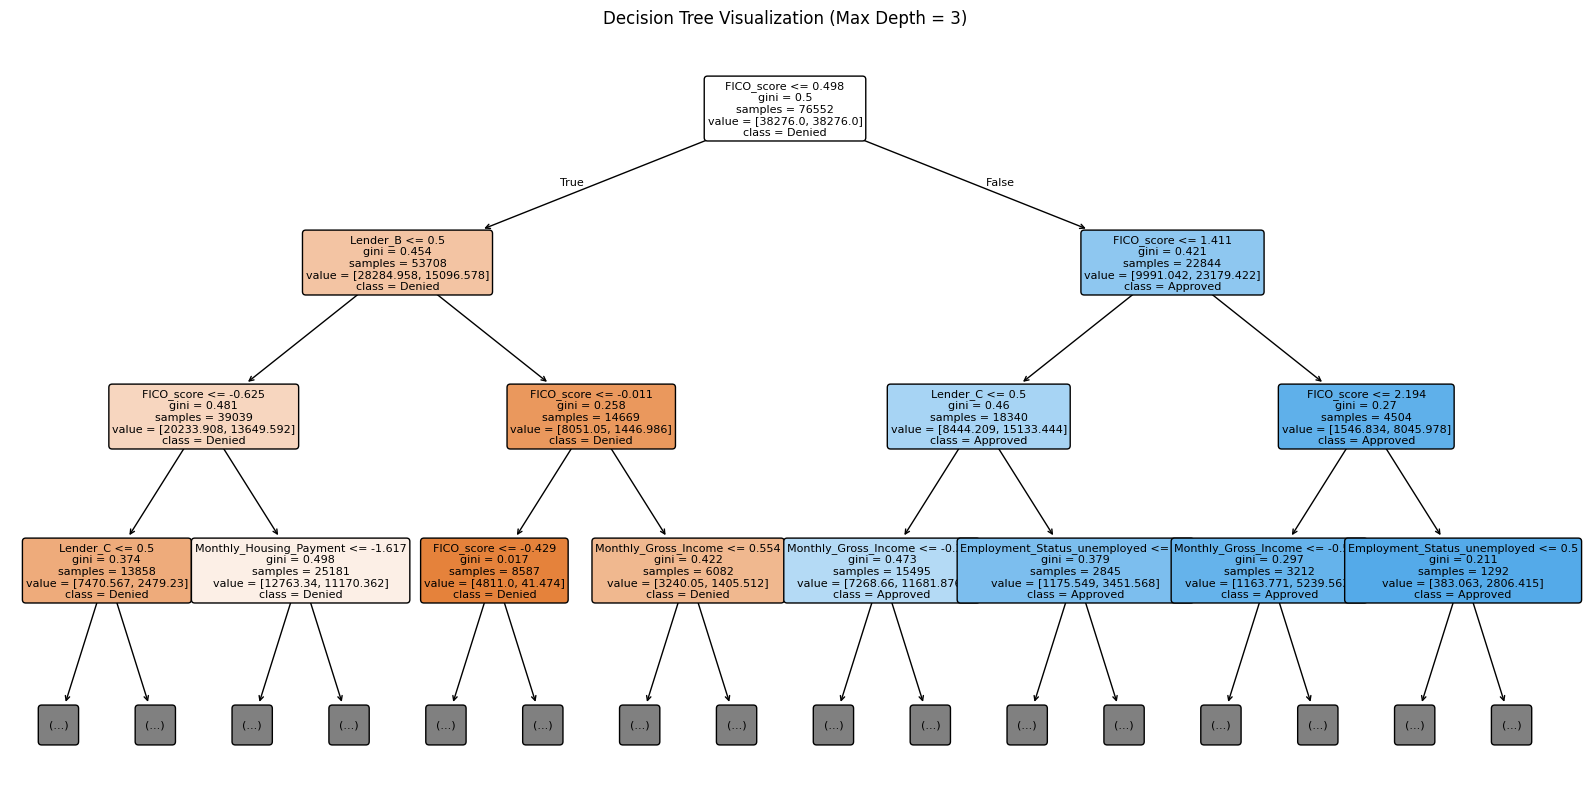

In [105]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Visualize a small portion of the Decision Tree for interpretability
plt.figure(figsize=(20, 10))
plot_tree(decision_tree_model,
          feature_names=X_train.columns,
          class_names=['Denied', 'Approved'],
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3) # Limiting depth for better visualization
plt.title('Decision Tree Visualization (Max Depth = 3)')
plt.show()

### Compare the performance of the Logistic Regression and Decision Tree models.


1.   Compare the performance of the Logistic Regression and Decision Tree models.

| Metric                  | Logistic Regression | Decision Tree |
| :---------------------- | :------------------ | :------------ |
| **Accuracy**            | 0.69                | 0.83          |
| **ROC AUC Score**       | **0.7661**          | 0.5717        |
| **Precision (Approved=1)** | 0.22                | 0.24          |
| **Recall (Approved=1)** | **0.70**            | 0.24          |
| **F1-score (Approved=1)**  | **0.33**            | 0.24          |

The decision tree shows a higher overall accuracy compared to logistic regression, but because the dataset is imbalanced, accuracy can be misleading.

2.   Evaluate and compare both models using key metrics such as ROC-AUC, Accuracy, Precision, Recall, and F1-score.

ROC-AUC logistic regression significantly outperforms the decision tree in its ability to distinguish between approved and denied loans across all possible thresholds. Both models have low precision for the approved class, meaning that when they predict an approval, they are correct only about 22-24% of the time. This indicates a high number of false positives. Logistic regression is much better at identifying actual approved loans than the decision tree. This is crucial for the minority class, as it means logistic regression is better at capturing all the truly approvable applications. Logistic regression has a better balance between precision and recall for the positive class compared to the decision tree.

3. Plot and interpret the confusion matrices for both models. Discuss what false positives and false negatives mean in the business context (for example, approving risky applicants vs. rejecting qualified ones).

Logistic Regression:
    ```
    [[11822,  5241],
     [  617,  1459]]
    ```
    
There are 11822 true negatives, meaning they were correctly predicted as denied when they should have been denied. There were 5241 false positives, which were predicted as approved, but actuall denied. They were approved when they should have been denied. The business impact of approving risky applicants leads to potential financial losses for the lender if the loan defaults. There were 617 false negatives, meaning they were predicted as denied, but actually approved. They were denied when they should have been approved. The business impact of rejecting qualified applicants is a lot of missed business opportunities and potential loss of revenue and customers for the lender. There were 1459 true positives which were correctly predicted as approved when they should have been approved.

Decision Tree:
    ```
    [[15399,  1664],
     [ 1576,   500]]
    ```

There were 15399 true negatives which were correctly predicted as denied when they should have been denied. There were 1664 false positives. They were predicted as approved, but actually denied. They were approved when they should have been denied. Again, the business impact is approving risky applicants, though the decision tree has significantly fewer false positives than logistic regression. There were 1576 false negatives. They were predicted as denied, but actually approved. They were denied when it should be approved. The business impact is again rejecting qualified applications, but the decision tree has a much higher number of false negatives than logistic regression, indicating it misses many potential good approvals. There are 500 true positives where it was correctly predicted as approved when it should have been approved.
  
The logistic regression model prioritizes minimizing false negatives, capturing more approved loans, at the cost of more false positives. The decision tree model prioritizes minimizing false positives, having fewer risky approvals, at the cost of significantly more false negatives.

4. Identify which model best captures the target event (loan approval) and explain why.
The logistic regression model best captures the target event of loan approval for this scenario. While its overall accuracy is lower, its significantly higher ROC-AUC score (0.7661 vs 0.5717)and much better recall for the approved class (0.70 vs 0.24) indicate that it is more effective at identifying actual loan approvals. Missing out on qualified applicants, equating to false negatives, can be a significant business loss. The logistic regression model is better at finding these positive cases, even if it comes with a higher rate of false alarms/false positives. The class weight balanced parameter helped logistic regression achieve a better balance in predicting the minority class.
5. Justify your model choice from both technical (performance, interpretability) and business (actionability, trust, and decision-making) perspectives.
On the technical side, the logistic regression model has a better performance with the ROC-AUC score and recall, better interpretability, and robustness to multicollinearity. A better ROC-AUC score indicates better discriminatory power across multiple thresholds, meaning it can separate approved from denied applications more effectively. It has a higher recall for the minority class, which is crucial for identifying approvals accurately. The logistic regression coefficients can be interpreted as the change in log-odds of approval for a one-unit change in the predictor, offering clear insights into the feature impact. While decision trees are less sensitive to multicollinearity, logistic regression can still perform well if redundant features are handled, which we did.

On the business side, by having a higher recall for approved loans, the model ensures that fewer legitimate applicants are rejected, maximizing potential revenue. The model's interpretability helps us understand why a loan might be approved or denied, buildin trust in the system and providing clear action plans for applicants. While it has more false positives, this can be managed by adjusting the classification threshold to balance between risk (false positives) and opportunity (true positives). If the cost of a false positive is very high, the threshold can be increased.

6. Indicate the cutoff threshold you used and why it makes sense for this scenario.
The default cutoff threshold for both models 0.5. It makes sense for this scenario because it means that if the predicted probability of approval is 0.5 or greater, the application is classified as approved. Otherwise, it's denied.

In [106]:
model = logistic_model

In [107]:
# Save your model as .pkl file for streamlit app development
import pickle

filename = 'my_model.pkl'  # Choose a path and descriptive filename with .pkl extension

# Open the file in binary write mode ('wb')
with open(filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Model saved successfully to {filename}")


Model saved successfully to my_model.pkl


**Question:**
Which model do you recommend and why? (Provide both technical and business reasoning.)

**Answer:**
I recommend the logistic regression model over the decision tree model. The technical reasoning is that the logistic regression model has a higher ROC-AUC score, better recall for the minority class, a better F1-score for the minority class, and easy intepretability. From a business perspective, the higher recall of the logistic regression model means fewer legitimate loan applicants are wrongly denied. This equates to maximizing potential revenue. While logistic regression initially shows more false positives (approving risky applicants), this can be managed by adjusting the probability threshold. Lenders can fine-tune this threshold based on their specific risk appetite: a higher threshold reduces risk at the cost of some missed opportunities, and vice-versa. This flexibility is a significant business advantage. The interpretability of logistic regression allows us to understand the drivers behind approval decisions, which helps in communicating with applicants, building trust, and potentially offering advice for future applications. The cost of a false negative (rejecting a qualified lender) often involves lost revenue and customer dissatisfaction, while the cost of a false positive (approving a risky borrower) involves potential default losses. Given the significantly better recall, logistic regression balances these trade-offs more effectively in this scenario to capture more good loans, which usually outweighs the cost of some additional false positives that can be mitigated by further checks or threshold adjustments.

## 5. Recommendations
In this final section, summarize your key findings and provide concise business recommendations based on your analysis.


**Write a short paragraph including:**  
- A brief summary of your main findings from the analysis and model comparison.  
- The key factors that most influence loan approval.  
- Your recommendations on data or model based on the results  (for example, how approval decisions could be improved or better understood).  
- One next step you would take to improve the model or extend the analysis further.  


**Add your paragraph here:**

My analysis revealed that loan approval is significantly influenced by FICO score, monthly gross income, granted loan amount, and monthly housing payment, with FICO score being the most influential. The dataset exhibits a substantial imbalance, with only about 10.85% of loans being approved. Comparing predictive models, the logistic regression model emerged as superior to the Decision Tree, primarily due to its higher ROC-AUC (0.7661) and significantly better recall for approved loans (0.70), which is critical for identifying potential revenue. I recommend the logistic regression model, but with careful consideration of the classification threshold to balance the costs of false positives (risky approvals) and false negatives (missed opportunities). Regarding lender matching to improve total payout, my analysis showed Lender A has a notably higher approval rate than Lenders B and C. This suggests a strategic opportunity to prioritize sending a larger proportion of applications, especially those that are borderline or have slightly lower FICO scores but are still within an acceptable risk profile, to Lender A. This could maximize the overall volume of approved loans and, consequently, the total payout from successful lending. Conversely, applications with higher risk indicators might be exclusively directed to the most conservative lender if their criteria are met, or declined outright if not, to minimize potential losses.

---



**Question:**  What trade-offs or risks should the company be aware of when using this model?  

**Answer:**
When using the logistic regression model, the company should be aware of false positives (approving risky loans) and data quality and bias. The model has a relatively low precision for approved loans (0.22), meaning it will predict approved for many applications that are actually denied. This leads to a higher number of false positives, which represent risky loans that could potentially default and result in financial losses for the lender. The trade-off is between maximizing approvals (high recall) and minimizing bad loans (high precision). While logistic regression is generally interpretable, the model is still a simplification of complex real world financial behavior and may not capture all of the nuances. The model's performance relies heavily on the quality and representativeness of the training data. If there are underlying biases in the loan approval data, the model might amplify these biases. Economic conditions and applicant profiles change over time. A model trained on historical data may not perform optimally in significantly different future environments, necessitating periodic retraining and monitoring. Optimizing for recall to capture more approvals might come at the expense of precision (more risky loans). The company needs to decide its primary objective and adjust the model's threshold accordingly.

**Question:** How confident are you in your model’s generalizability — what might change its performance in real-world use?   

**Answer:**
I have moderate confidence in the model's generalizability, primarily because of the stratified split, removed outliers, and careful selection of features. We ensured the class distribution of approved loans is maintained the the training and test sets, which helps in evaluating performance on the minority class. In real-world use, economic shifts, changes in interest rates, or changes in customer demographics could make the historical data less relevant over time. A model trained on past data may not generalize well to future market conditions. Undetected biases that influence loan approval may also affect the model's predictions, as well as data input errors. Finally, changes in the lenders risk tolerance or criteria may cause the model to degrade.


**Question:** If you had access to additional data, what new feature would you collect to strengthen this model?

**Answer:**
If I had access to additional data, the new features I would collect to strengthen this model would be debt-to-income ratio, credit utilization ratio, years of credit history, and loan term and interest rate. Debt-to-income ratio is a great indicator of a borrower's ability to manage their monthly payments. A high DTI is a strong predictor of default risk,and this would be more informative than monthly gross income and monthly housing payment alone. Credit utilization ratios show how much of a borrower's available credit they are actually using. High utilization can indicate financial distress or over-reliance on credit, which is a strong risk factor. A longer, established credit history typically indicates more financial stability. This could provide valuable context beyond just the FICO score itself. Lastly, even though granted loan amount is present in the dataset, details about the requested loan's term and the proposed interest rate could significantly influence approval decisions and risk assessment.